In [1]:
# !pip install -U pip wheel
# !pip install -q -r /Users/ryan/github/lltk/requirements.txt
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
sys.path.insert(0,'/Users/ryan/github/lltk')
sys.path.insert(0,'/Users/ryan/github/logmap')
from llmdh import *
import prosodic
from prosodic import Word
prosodic.USE_CACHE=False
import plotnine as p9
p9.options.figure_size=11,8
pd.options.display.max_rows=200

In [2]:
def add_new_data(df):
    prompt2type = dict(zip(df.prompt, df.prompt_type))

    newdata = []
    # with open('/Users/ryan/Dropbox/Prof/Data/data.newpoems.json') as f: 
    with open('/Users/ryan/Downloads/data.newpoems2.json') as f: 
        for d in json.load(f):
            newdata.append({
                'model':d['prompt']['model'],
                'temperature':d['prompt']['temperature'],
                'prompt':d['prompt']['user_prompt'],
                'poem':d['response'].split('</think>')[-1].strip()
            })
    
    df2=pd.DataFrame(newdata)
    df2['prompt_type'] = df2.prompt.apply(lambda x: prompt2type.get(x, 'Unknown'))
    return pd.concat([df,df2])

def get_df_poems(min_lines=8):
    df_poems = pd.read_pickle('data.allpoems.pkl').fillna('')
    
    excl_prompts=[
        'Write an unryhmed poem in the style of Shakespeare\'s dramatic monologues.',
        'Write a poem in the style of Shakespeare\'s dramatic monologues.',
        'Write a poem in the style of e.e. cummings',
        # 'Write a poem in the style of Walt Whitman.',
        # "Write an ryhmed poem in the style of Shakespeare's sonnets.",
        # "Write a poem in the style of Emily Dickinson.",
        # "Write a poem in the style of Walt Whitman.",
        'Write a poem in the style of Wallace Stevens.',
        # "Write a poem in blank verse.",
        'Continue the following poem:\n\nTyping, typing, fingers on the keyboard\nThe keys crack and bend under sweat and weight,\n'
    ]
    df_poems = add_new_data(df_poems)
    df_poems = df_poems[~df_poems.prompt.isin(excl_prompts)]
    # df_poems['num_lines'] = pd.to_numeric(df_poems['num_lines'], errors='coerce')
    # odf = df_poems.query(f'num_lines >= {min_lines}')
    return df_poems

In [3]:
df=get_df_poems()
df_human = df[df.model.str.startswith('b.')]
df_human.attrhyme.value_counts()

attrhyme
y      45440
       12904
n       1245
y n       98
Y          1
Name: count, dtype: int64

In [4]:
def get_allpoems_with_rhyme_data(min_lines=10):
    df_poems = get_df_poems()
    odf=pd.read_csv('data.allpoems.rhyme_data4.tsv', sep='\t')
    odf['poem_hash'] = odf['poem']
    df_poems['poem_hash'] = df_poems['poem'].apply(hashstr)
    df2 = odf[['num_rhyming_lines','poem_hash', 'num_lines']].merge(df_poems, on='poem_hash', how='inner', suffixes=['', '_1'])
    df2['num_rhyming_lines'] = pd.to_numeric(df2['num_rhyming_lines'], errors='coerce')
    df2['num_lines'] = pd.to_numeric(df2['num_lines'], errors='coerce')
    df2['perc_rhyming_lines'] = df2['num_rhyming_lines'] / df2['num_lines']
    df2['poem_rhymes'] = (df2['num_rhyming_lines'] > 0).apply(int)
    df2 = df2[df2.num_lines>=min_lines]
    return df2

df2 = get_allpoems_with_rhyme_data()
df2.model.value_counts()

model
gpt-3.5-turbo                            1878
ollama/olmo2:13b                         1576
b. 1750-1800                             1562
b. 1800-1850                             1541
b. 1700-1750                             1519
ollama/llama3.1:8b                       1500
b. 1650-1700                             1492
b. 1900-1950                             1468
b. 1850-1900                             1464
b. 1600-1650                             1457
deepseek/deepseek-chat                   1334
b. 1950-2000                             1183
gpt-4-turbo                              1119
claude-3-haiku-20240307                  1018
ollama/olmo2                             1004
ollama/llama3.1:70b                       989
claude-3-sonnet-20240229                  981
claude-3-opus-20240229                    962
gemini-pro                                927
llama2-uncensored:7b                      554
ollama/darkmoon/olmo:7B-instruct-q6-k     553
ollama/deepseek-r1:8b       

In [5]:
# df2.groupby(['model','prompt_type']).perc_rhyming_lines.mean().sort_values()

In [6]:
# df2.groupby('prompt').perc_rhyming_lines.mean().sort_values()

In [7]:
# df2.groupby(['model','prompt_type']).poem_rhymes.mean().sort_values()

In [8]:
# df3 = pd.concat(gdf for g,gdf in df2.groupby(['model','prompt']) if len(gdf)>=20)
# df3.groupby(['model','prompt_type']).mean(numeric_only=True).sort_values('poem_rhymes')

In [9]:
# df4 = df2.groupby(['model','prompt_type']).sum(numeric_only=True)
# df4['perc_rhyming_lines'] = df4['num_rhyming_lines'] / df4['num_lines']
# df4.perc_rhyming_lines.sort_values()

In [58]:
BAD_MODELS = {'ollama/darkmoon/olmo:7B-instruct-q6-k', 'ollama/deepseek-r1:8b'}

def get_figdf(min_lines=10, bad_models = BAD_MODELS, incl_humans=True, agg_models=False, incl_models=True):
    figdf = get_allpoems_with_rhyme_data(min_lines=min_lines)
    figdf = figdf[~figdf.model.isin(bad_models)]
    # figdf['fline']=figdf['poem'].apply(lambda x: x.strip().split('\n')[0])
    # figdf=figdf.drop_duplicates('fline')
    # len(df2), len(figdf)

    model_rename={
        'Chadwyck': 'Human',
        'claude-3-haiku-20240307': 'Claude Haiku (Anthropic)',
        'claude-3-opus-20240229': 'Claude Opus (Anthropic)',
        'claude-3-sonnet-20240229': 'Claude Sonnet (Anthropic)',
        'gemini-pro': 'Gemini Pro (Google)',
        'gpt-3.5-turbo': 'ChatGPT-3.5 (OpenAI)',
        'gpt-4-turbo': 'ChatGPT-4 (OpenAI)',
        'llama2-uncensored:7b': 'Llama 2 (Meta)',
        'ollama/darkmoon/olmo:7B-instruct-q6-k':'OLMo (Ai2)',
        'deepseek/deepseek-chat':'DeepSeek',
        'ollama/llama3.1:70b':'Llama 3.1 (Meta)',
        'ollama/llama3.1:8b':'Llama 3.1 (Meta)',
        'ollama/llama2-uncensored:latest':'Llama 2 (Meta)',
        'ollama/deepseek-r1:8b': 'DeepSeek R1',
        'ollama/olmo2':'OLMo2 (Ai2)',
        'ollama/olmo2:13b':'OLMo2 (Ai2)'
    }

    if agg_models:
        for k in model_rename:
            if 'claude' in k: model_rename[k]='Claude (Anthropic)'
            if 'gpt-' in k: model_rename[k]='ChatGPT (OpenAI)'

    if not incl_humans:
        figdf = figdf[~figdf.model.str.startswith('b.')]
    if not incl_models:
        figdf = figdf[figdf.model.str.startswith('b.')]

    
    humanpref = 'Poets '
    figdf['model']=figdf.model.apply(lambda x: model_rename.get(x,x) if not x.startswith('b.') else humanpref+x.replace('b.','born'))

    for k in ['prompt']:
        figdf[k] = pd.Categorical(
            figdf[k], 
            # categories=figdf.groupby(k).perc_rhyming_lines.median().sort_values(ascending=True).index,
            categories = sorted(figdf[k].unique(), reverse=True)
        )

    prompt_type_rename = {
        'MAYBE_rhyme':'LLM: Write a poem', 
        'DO_rhyme':'LLM: Write a rhyming poem', 
        'do_NOT_rhyme':'LLM: Write an unrhyming poem', 
        'Human':'Human: Poetic history'
    }
    prompt_types = ['Human','MAYBE_rhyme','DO_rhyme','do_NOT_rhyme']
    if not incl_humans:
        prompt_types.pop(0)
    figdf['prompt_type']=pd.Categorical(figdf['prompt_type'], categories=prompt_types)
    figdf['prompt_type']=figdf.prompt_type.apply(lambda x: prompt_type_rename.get(x,x))
    # return figdf.prompt_type.value_counts()
    # figdf.to_pickle('data.figdf.allpoems.pkl')

    figdf_human = figdf[figdf.model.str.startswith(humanpref)]
    figdf_nonhuman = figdf[~figdf.model.str.startswith(humanpref)]
    human_models = sorted(list(figdf_human.model.unique()))
    nonhuman_models = list(figdf_nonhuman.query('prompt_type == "LLM: Write an unrhyming poem"').groupby('model').perc_rhyming_lines.mean().sort_values(ascending=True).index)
    # nonhuman_models = list(figdf_nonhuman.groupby('model').perc_rhyming_lines.mean().sort_values(ascending=True).index)
    # nonhuman_models = sorted(list(figdf_nonhuman.model.unique()))
    models = human_models + [x for x in nonhuman_models if x not in human_models]
    figdf['model']=pd.Categorical(figdf['model'], categories=reversed(models))

    return figdf

# figdf = get_figdf(incl_humans=True, agg_models=True)
# figdf.groupby(['model','prompt']).size().sort_values().head(25)

In [48]:
figdf = get_figdf(incl_models=False)
figdf.attgenre.value_counts()

attgenre
                       10206
Sonnet                   294
Lyric                    260
Heroic couplets          231
Ode                      224
Hymn                     102
Metrical Psalm           101
Verse epistle             63
Pastoral poem             30
Epitaph                   28
Ballad                    24
Elegy                     15
Epigram                   15
Topographical poem        15
Dialect poem              14
Epithalamium               9
Modernist long poem        8
Dialogue                   6
Lullaby                    6
Metaphysical poem          5
Carol                      4
Rondeau                    3
Dramatic monologue         3
Riddle                     3
Acrostic                   3
Nonsense poem              3
Satire                     2
Epic poem                  1
Spenserian stanza          1
Sestina                    1
Complaint                  1
Villanelle                 1
Aubade                     1
Allegory                   1
Eulog

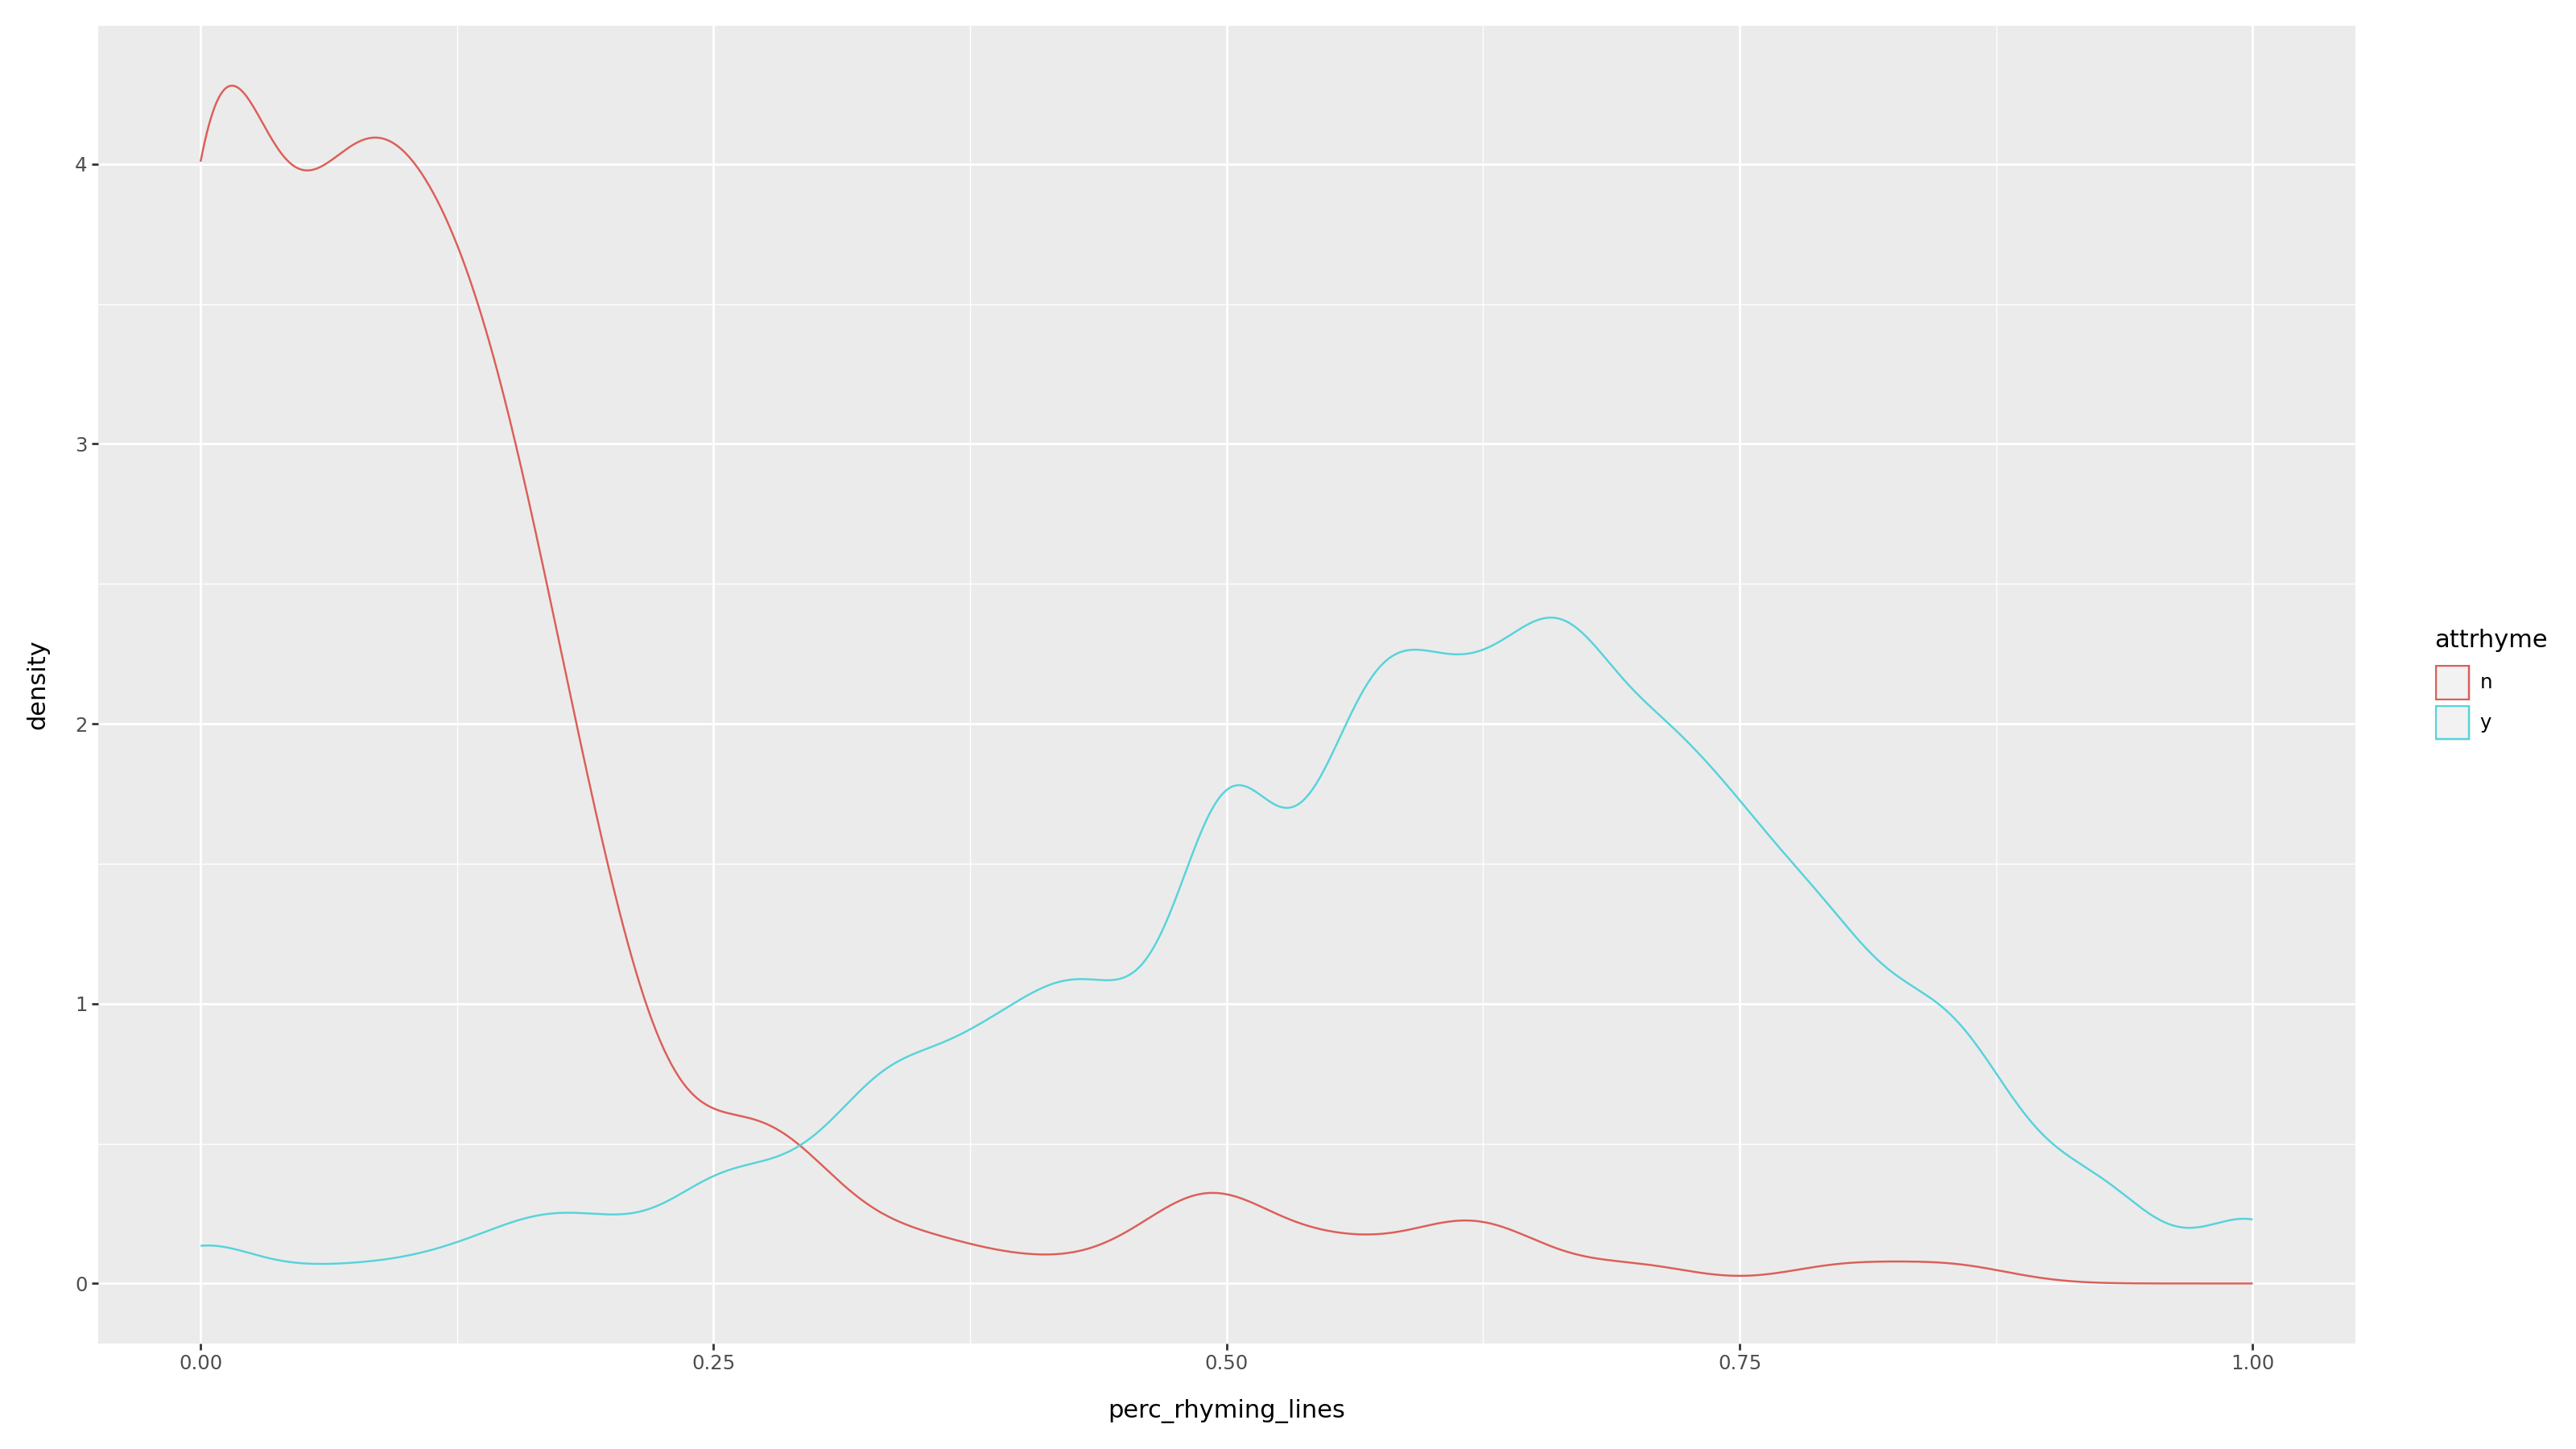

In [41]:
def plot_rhyme_test():
    figdf = get_figdf(incl_models=False)
    figdf = figdf[figdf.attrhyme.isin({'y','n'})]
    
    fig = p9.ggplot(figdf, p9.aes(color='attrhyme', x='perc_rhyming_lines'))
    fig += p9.geom_density()
    return fig

plot_rhyme_test()

In [43]:
s=figdf.attgenre.value_counts()
s[s>10]

attgenre
                      17441
Sonnet                  294
Lyric                   260
Heroic couplets         231
Ode                     224
Hymn                    102
Metrical Psalm          101
Verse epistle            63
Pastoral poem            30
Epitaph                  28
Ballad                   24
Elegy                    15
Epigram                  15
Topographical poem       15
Dialect poem             14
Name: count, dtype: int64

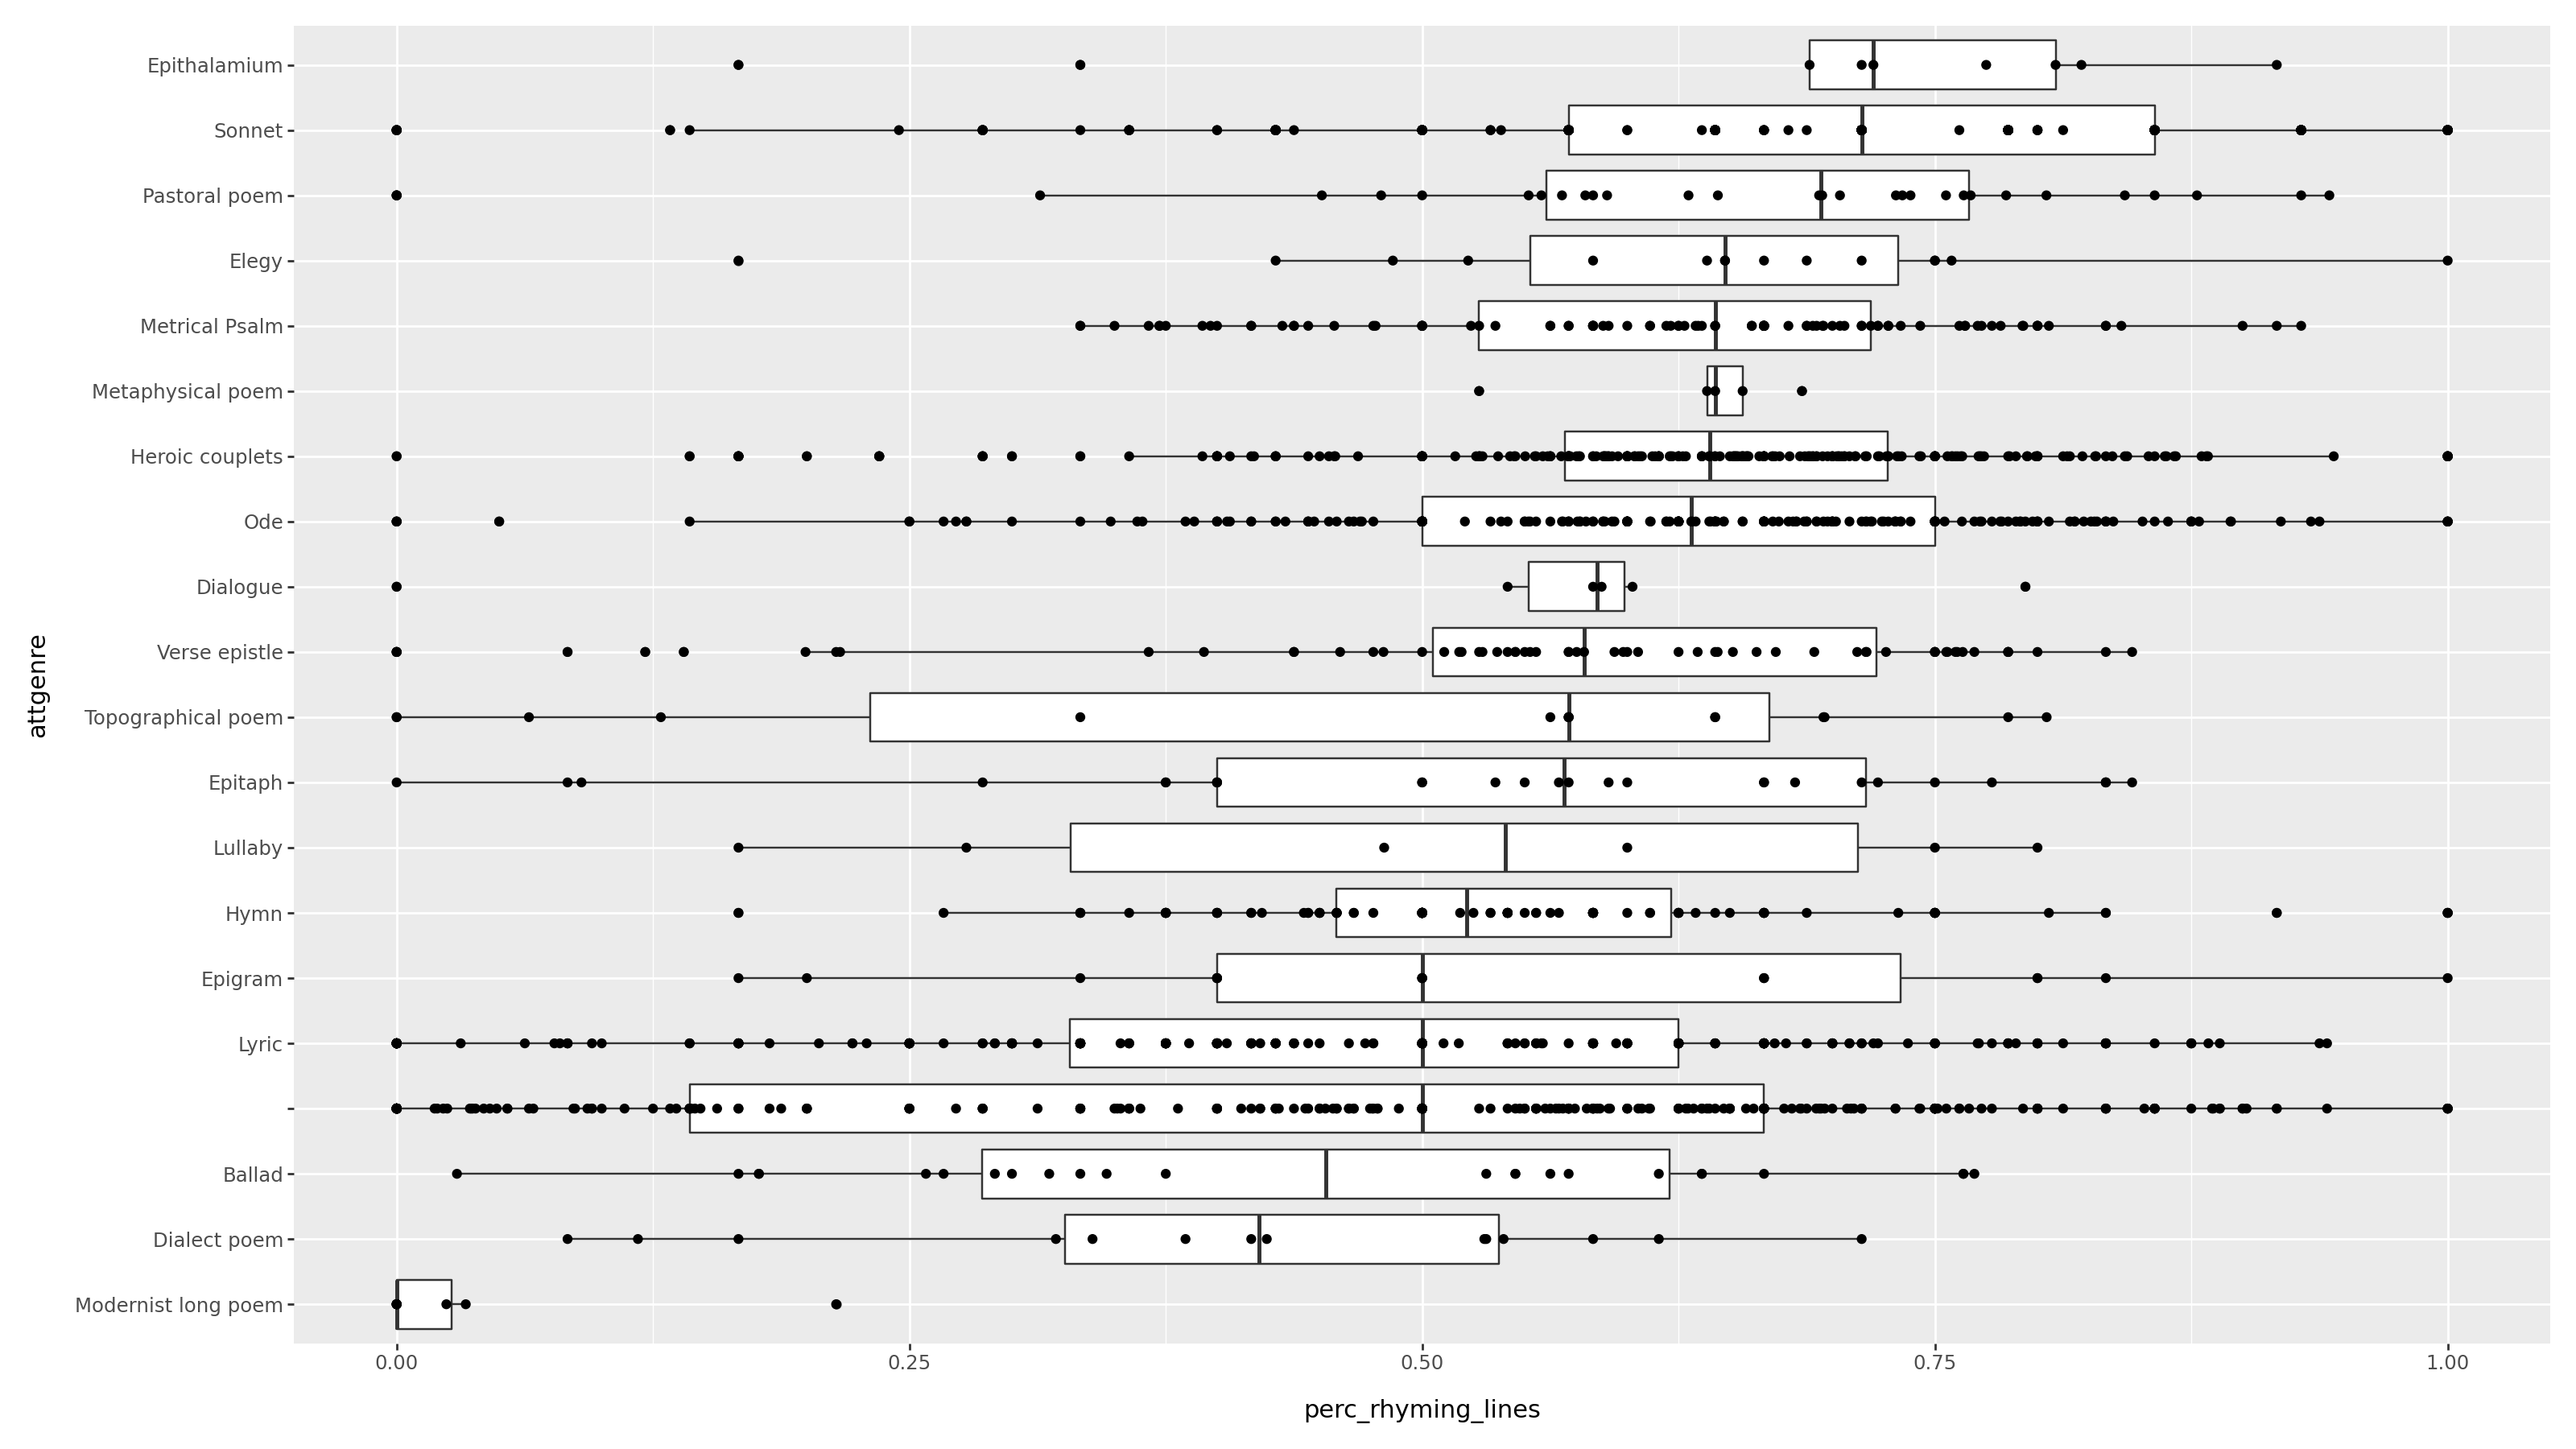

In [57]:

def plot_rhyme_genre():
    figdf = get_figdf(incl_models=False)
    # figdf = figdf[figdf.attrhyme.isin({'y','n'})]
    figdf = pd.concat(
        gdf.sample(frac=1).iloc[:300]
        for g,gdf in figdf.groupby('attgenre')
        if len(gdf)>=5
    )
    figdf['attgenre'] = pd.Categorical(
        figdf['attgenre'],
        categories=figdf.groupby('attgenre').perc_rhyming_lines.median().sort_values(ascending=True).index
    )
    
    fig = p9.ggplot(figdf, p9.aes(x='attgenre', y='perc_rhyming_lines'))
    fig += p9.geom_boxplot()
    fig += p9.geom_point()
    fig += p9.coord_flip()
    return fig

plot_rhyme_genre()

In [20]:
def plot_fig_avgs(x='model', color='prompt_type'):
    figdf=get_figdf().sample(frac=1)
    figdf['perc_rhyming_lines']*=100
    stats_df = figdf.groupby([x, color])['perc_rhyming_lines'].agg(
        mean_perc_rhyming=np.mean,
        stderr_perc_rhyming=lambda x: x.std() / np.sqrt(len(x)),
        count=len
    ).reset_index()

    # Create the plot with error bars
    fig = (p9.ggplot(stats_df, p9.aes(x=x, y='mean_perc_rhyming', color=color))
        + p9.geom_point(
            size=1, 
            #    position=p9.position_dodge(width=0.25)
        )
        + p9.geom_line(p9.aes(group=color), linetype='dashed', alpha=.75)
        + p9.geom_errorbar(
            p9.aes(ymin='mean_perc_rhyming - stderr_perc_rhyming', 
                    ymax='mean_perc_rhyming + stderr_perc_rhyming'),
            width=0.5,
            #    position=p9.position_dodge(width=0.5)
        )
        + p9.labs(
            x='Model',
            y='Percentage of Lines Rhyming',
            title='Formal Stuckness in AI:\nEven when prompted not to rhyme, LLMs rhyme more often than contemporary verse'
        )
        + p9.theme_minimal()
        + p9.coord_flip()
        + p9.scale_y_continuous(limits=[0,100])
        + p9.geom_hline(yintercept=50, linetype='dashed', color='gray', alpha=.5)
    )
    p9.options.figure_size=(12,8)
    return fig

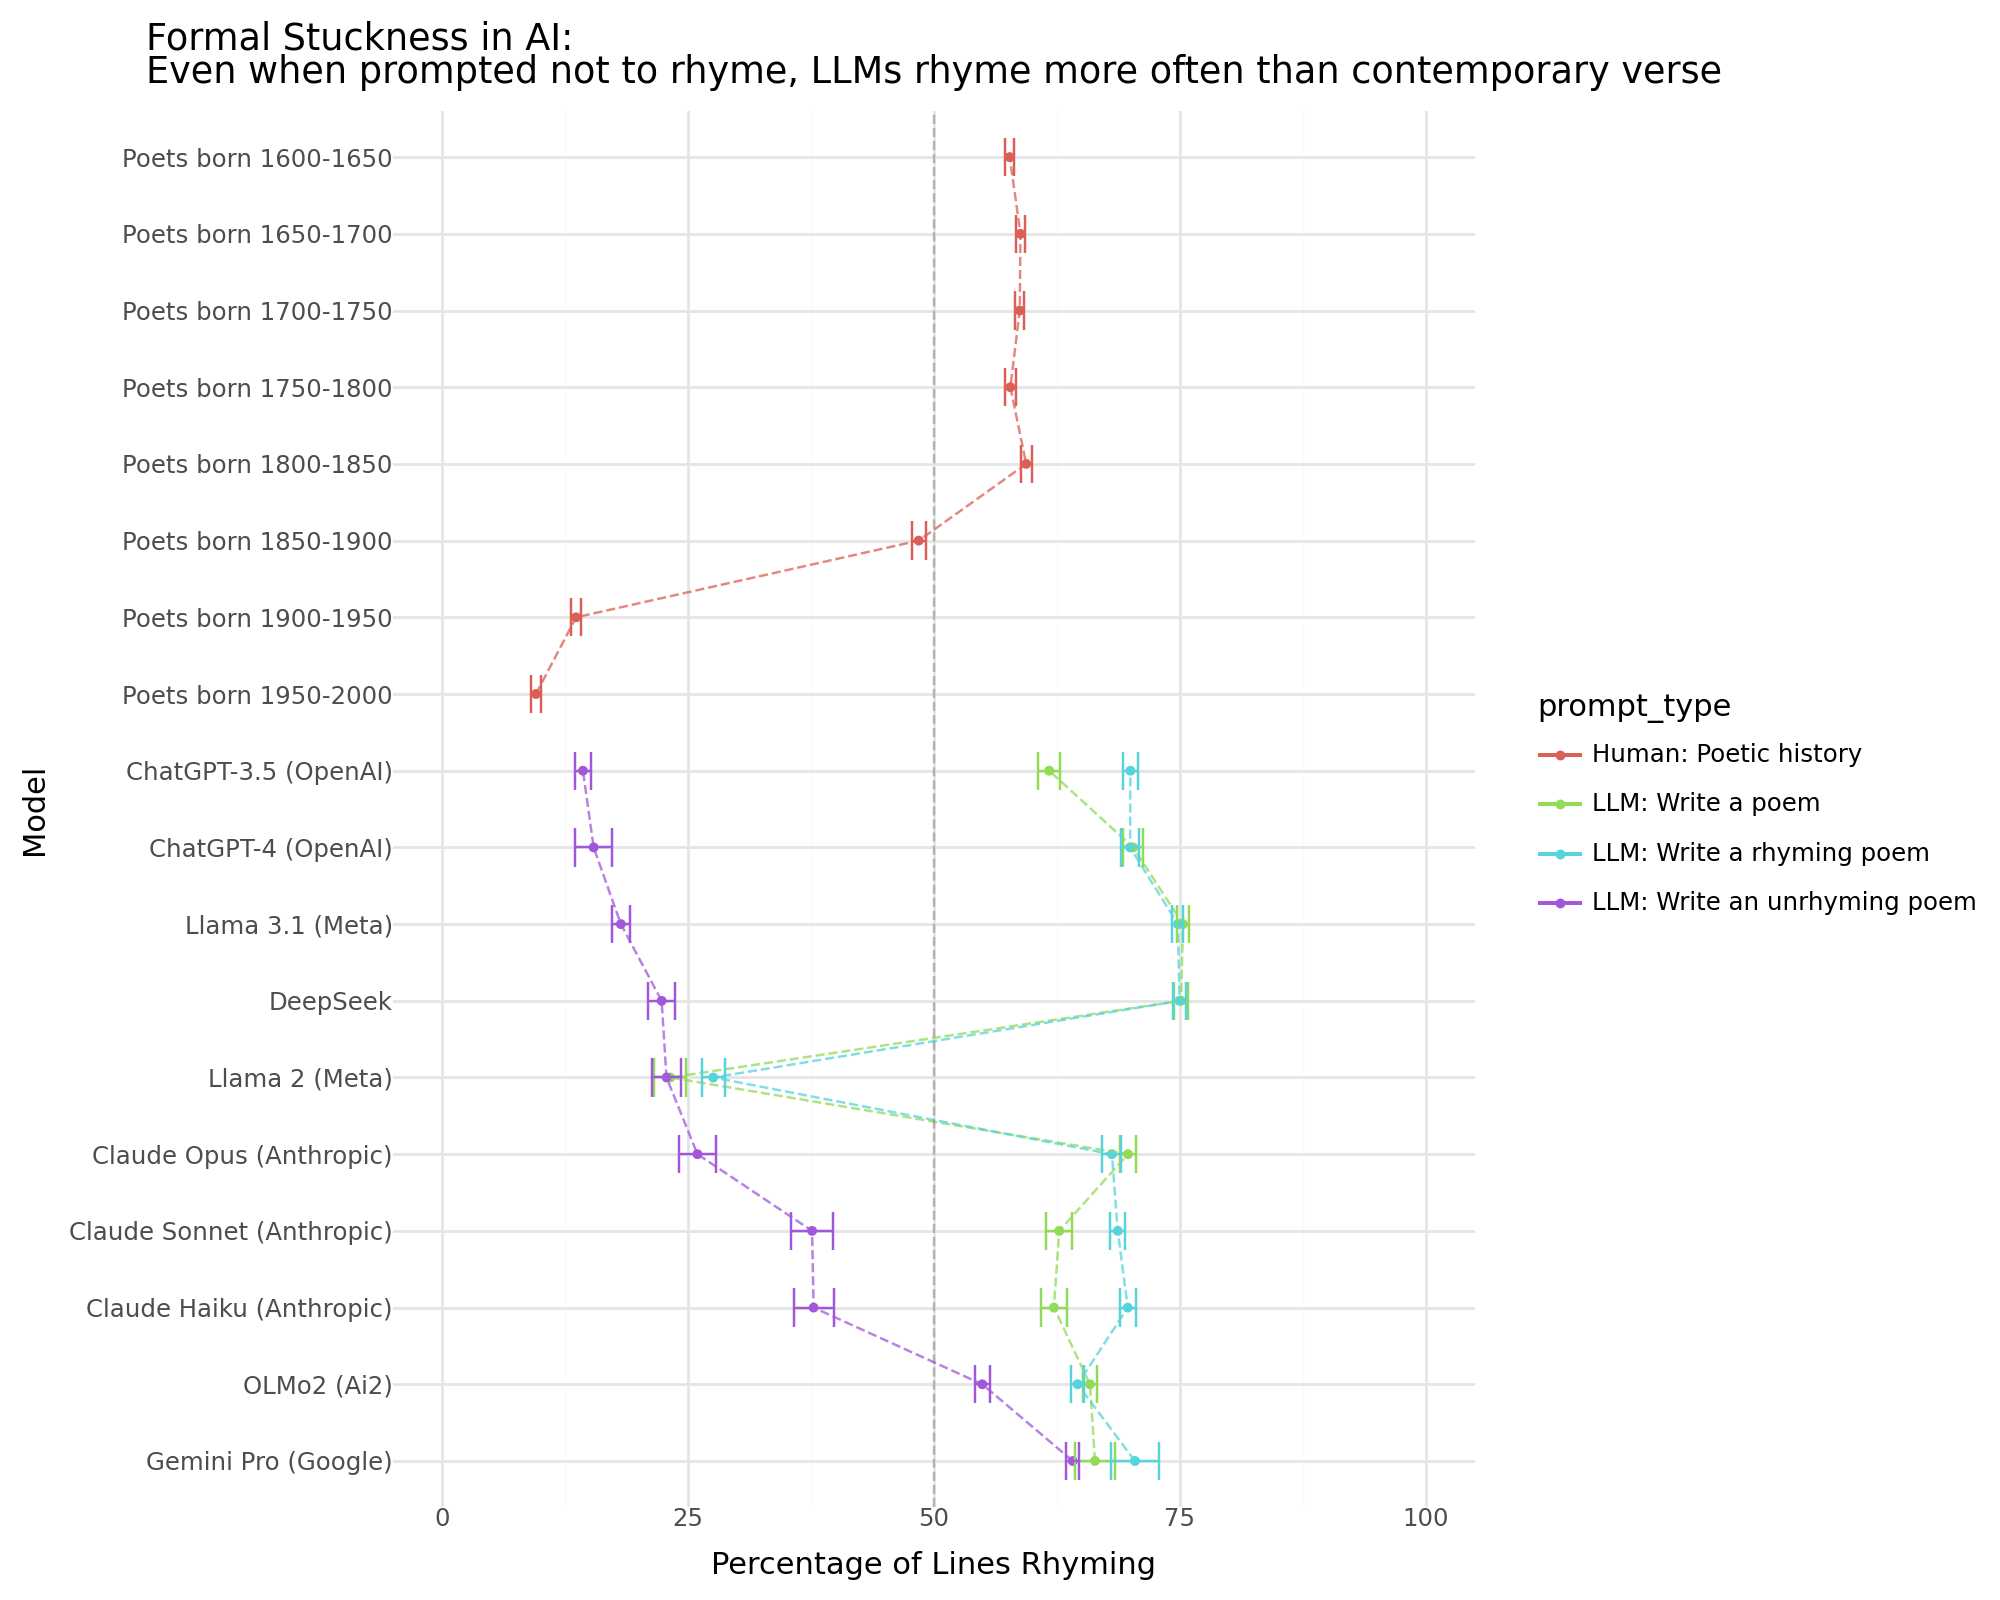

In [21]:
plot_fig_avgs()

In [22]:
def plot_fig_avgs_prompts(x='prompt', color='model', model='ChatGPT-3.5 (OpenAI)'):
    p9.options.figure_size=(16,9)
    figdf=get_figdf(incl_humans=False, agg_models=True, bad_models=BAD_MODELS|{'ollama/llama2-uncensored:latest', 'llama2-uncensored:7b'})
    # Convert mixed type columns to string to avoid comparison errors
    figdf[x] = figdf[x].astype(str)
    if color in figdf.columns:
        figdf[color] = figdf[color].astype(str)
    
    figdf['perc_rhyming_lines']*=100
    stats_df = figdf.groupby([x, color])['perc_rhyming_lines'].agg(
        mean_perc_rhyming=np.mean,
        stderr_perc_rhyming=lambda x: x.std() / np.sqrt(len(x)),
        count=len
    ).reset_index()
    
    # prompts = list(figdf.sort_values('prompt_type').prompt.drop_duplicates())
    prompts = stats_df.groupby(x).mean_perc_rhyming.median().sort_values().index
    stats_df['prompt'] = pd.Categorical(stats_df['prompt'], categories=prompts)
    
    # Get unique prompt types and assign colors
    if 'prompt_type' in figdf.columns:
        prompt_types = figdf['prompt_type'].unique()
        Set1 = [
        # '#e41a1c',  # Red
        '#377eb8',  # Blue
        '#984ea3',  # Purple
        '#4daf4a',  # Green
        '#ff7f00',  # Orange
        '#ffff33',  # Yellow
        '#a65628',  # Brown
        '#f781bf',  # Pink
        '#999999'   # Gray
        ]
        prompt_type_colors = dict(zip(prompt_types, Set1))
        
        # Map prompts to their types and colors
        prompt_to_type = figdf.set_index('prompt')['prompt_type'].to_dict()
        prompt_colors = {prompt: prompt_type_colors[prompt_to_type[prompt]] 
                        for prompt in prompts if prompt in prompt_to_type}
    
    # Create the plot with error bars
    fig = (p9.ggplot(stats_df, p9.aes(x=x, y='mean_perc_rhyming', color=color))
        + p9.geom_point(
            size=1,
            # position=p9.position_dodge(width=0.25)
        )
        + p9.geom_line(p9.aes(group=color), linetype='dashed', alpha=.75)
        + p9.geom_errorbar(
            p9.aes(ymin='mean_perc_rhyming - stderr_perc_rhyming',
                  ymax='mean_perc_rhyming + stderr_perc_rhyming'),
            width=0.5,
            # position=p9.position_dodge(width=0.5)
        )
        + p9.labs(
            x='Model',
            y='Percentage of Lines Rhyming',
            title='Formal Stuckness in AI:\nEven when prompted not to rhyme, LLMs rhyme more often than contemporary verse'
        )
        + p9.theme_minimal()
        + p9.coord_flip()
        + p9.scale_y_continuous(limits=[0,100])
        + p9.geom_hline(yintercept=50, linetype='dashed', color='gray', alpha=.5)
    )
    
    # Customize axis text colors based on prompt_type
    if 'prompt_type' in figdf.columns:
        # Create a theme element to color the axis text
        colored_theme = p9.theme(
            axis_text_y=p9.element_text(color=[prompt_colors.get(tick, 'black') for tick in prompts])
        )
        fig = fig + colored_theme
    fig.save('fig.rhyme_prompts.png')
    return fig

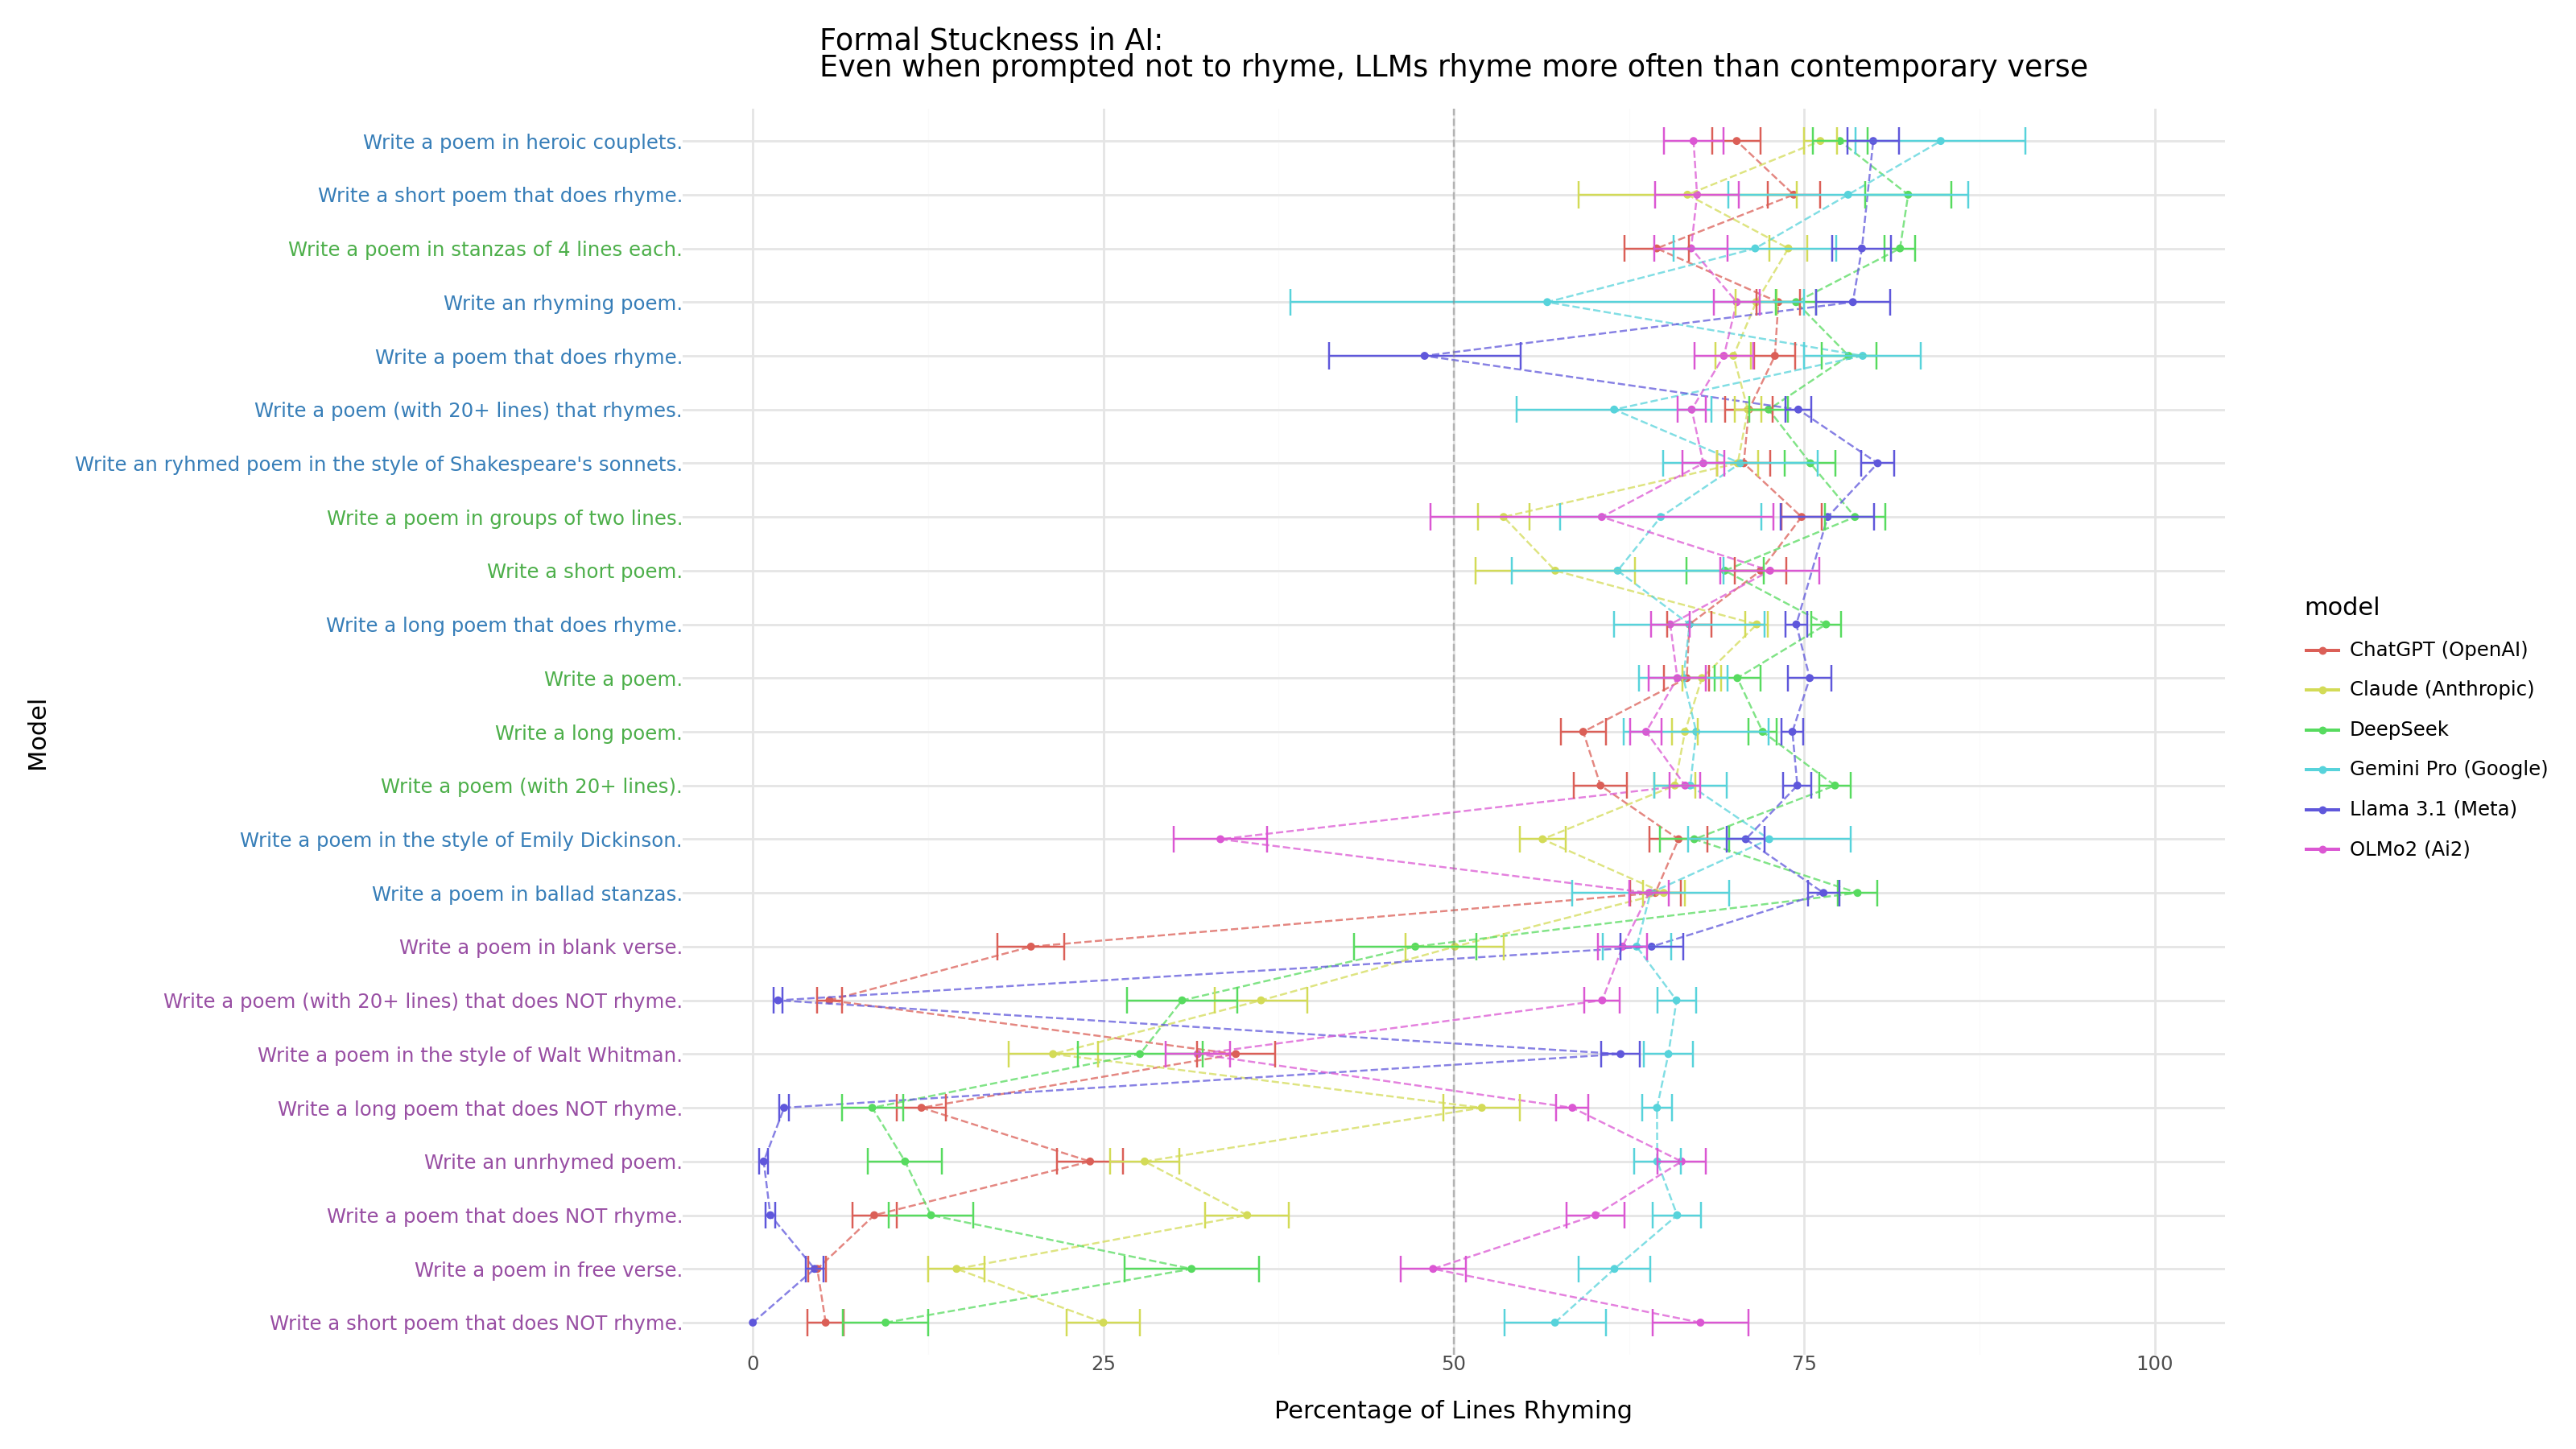

In [23]:
plot_fig_avgs_prompts()

In [15]:

def plot_fig(min_lines=10, value='perc_rhyming_lines'):
    p9.options.figure_size=(10,8)
    figdf = get_figdf(min_lines=min_lines)
    # figdf_nonhuman_smpl = figdf_nonhuman#.groupby(['model','prompt']).sample(n=100, replace=True).drop_duplicates('poem')    
    # figdf_human['prompt_type'], figdf_human['model'] = figdf_human['model'], figdf_human['prompt_type']
    # figdf = pd.concat([figdf_human, figdf_nonhuman_smpl])
    

    figdf[value]*=100
    figdf[f'{value}_bin'] = figdf[value].apply(lambda x: int(round(x,0)))
    figdf2=pd.concat(
        gdf.iloc[:1].assign(poem_count=len(gdf))
        for g,gdf in figdf.groupby(['prompt_type','model',f'{value}_bin'])
    )

    fig=p9.ggplot(figdf, p9.aes(x='model', y=value))
    # fig=p9.ggplot(figdf, p9.aes(x='prompt_type', y=value))
    fig+=p9.theme_classic()
    fig+=p9.theme(axis_text_x=p9.element_text(angle=90))
    fig+=p9.geom_point(p9.aes(size='poem_count'), shape='x', data=figdf2, alpha=.9)
    fig+=p9.geom_boxplot(alpha=.8, outlier_shape='')
    # fig+=p9.facet_wrap('model', nrow=9, scales='free_y')
    fig+=p9.facet_wrap('prompt_type', nrow=9, scales='free_y')
    fig+=p9.labs(
        title="Formal Stuckness in AI: even when told not to rhyme, most LLM-generated poems rhyme anyway",
        y='Percent of lines rhyming',
        x='Type of LLM model',
        size='Number of poems',
        caption=''
    )

    # Add a horizontal line for the overall median
    latest_median = figdf[figdf.model=='b. 1950-2000'][value].median()
    fig += p9.geom_hline(yintercept=latest_median, linetype='dashed', color='red')

    anndata = figdf[(figdf.model == 'b. 1950-2000') & (figdf.prompt_type.str.contains('Human'))].sample(frac=1)
    anndata[value] = anndata[value].median()
    anndata=anndata.iloc[:1]

    fig+=p9.geom_text(data=anndata, label='Median for contemporary verse', ha='left', va='bottom', size=8, color='red', nudge_y=1, nudge_x=-1.1)

    fig+=p9.coord_flip()
    fig.save(f'fig.rhyme_box_plots.{value}.v5.png')
    return fig

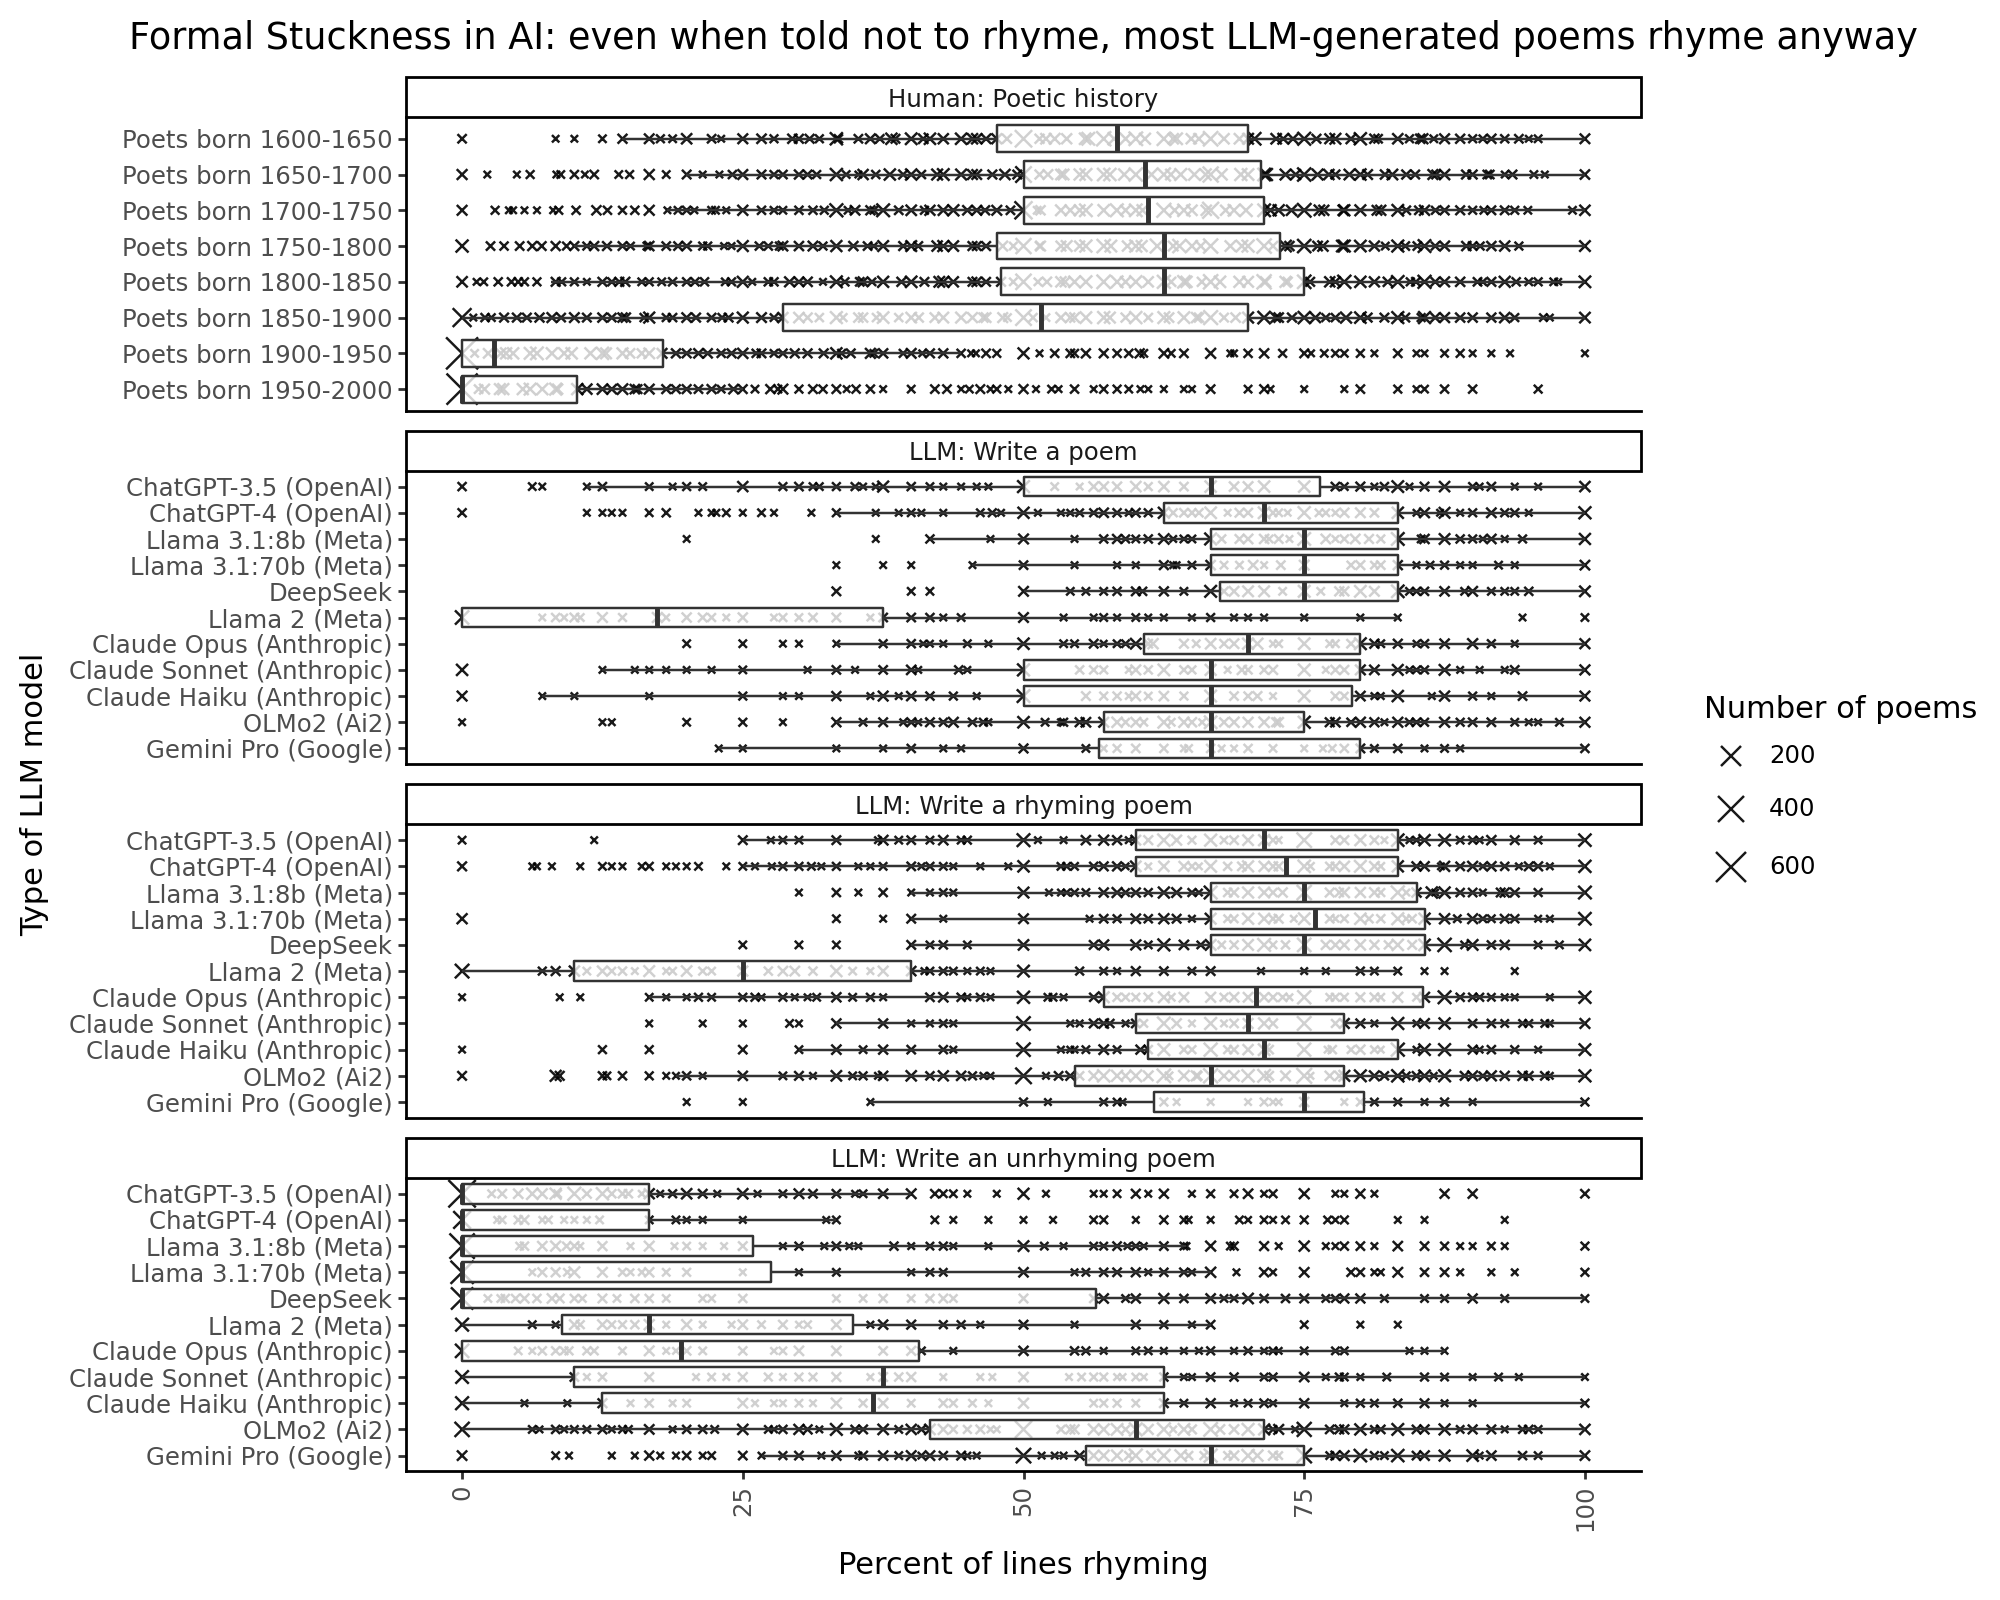

In [16]:
plot_fig(min_lines=10)

In [17]:
# fig=p9.ggplot(figdf, p9.aes(x='prompt_type', y='perc_rhyming_lines'))
# fig+=p9.theme_classic()
# fig+=p9.theme(axis_text_x=p9.element_text(angle=90))
# # fig+=p9.geom_violin(alpha=.75)
# fig+=p9.geom_point(p9.aes(size='poem_count'), shape='x', data=figdf2, alpha=.9)
# fig+=p9.geom_boxplot(p9.aes(color='prompt_type'), alpha=.8, outlier_shape='')
# # fig+=p9.geom_smooth()
# # fig+=p9.facet_grid('model~prompt')
# # fig+=p9.facet_wrap('model', ncol=7)
# # fig+=p9.facet_wrap('prompt_type', ncol=3)
# # fig+=p9.facet_wrap('prompt_type', ncol=3)
# # fig+=p9.facet_grid('model~prompt_type')
# # figdf['prompt_type']=pd.Categorical()
# fig+=p9.labs(
#     title="Formal Stuckness in AI: even when told not to rhyme, most LLM-generated poems rhyme anyway",
#     y='Percent of lines rhyming',
#     x='LLM temperature parameter',
#     size='Number of lines',
#     # caption='Prompts used, in order of least to most rhymes:\n- '+'\n- '.join(figdf.prompt.unique())
# )
# fig+=p9.coord_flip()
# # fig.save('fig.rhyme_box_plots.3way.png')
# fig

In [18]:

fig=p9.ggplot(figdf, p9.aes(x='prompt', y='perc_rhyming_lines', size='num_lines'))
fig+=p9.theme_classic()
fig+=p9.geom_boxplot(p9.aes(color='model'), alpha=.5, outlier_shape='')
fig+=p9.geom_boxplot(alpha=.25, outlier_shape='')
# fig+=p9.geom_point(shape='x')
# fig+=p9.facet_grid('model~prompt')
# fig+=p9.facet_wrap('model')
fig+=p9.coord_flip()
fig+=p9.labs(
    title='Formal Stuckness: varying the prompt to produce unrhymed verse produces no significant effect on rhyming',
    x='Percent of lines rhyming',
    y='Prompt to LLM',
    color='LLM model'
)
fig

NameError: name 'figdf' is not defined